In [1]:
import sys
sys.path.append('..')
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model_rate_based import CANN_DDM_model
#from make_conn_mat import make_edge_conn_mat, make_bump_conn_mat
from make_conn_mat_updated import make_conn_mat_from_kernel
from tqdm import tqdm
import pickle
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

In [12]:
num = 1024
edge_pop = {'num_E': 1024, 'tau_E': 2, 'c_EB': 5,
             'alpha_E': 1, 'sigma_E': 10, 'clamp_frac_E': 0.1, 
            'edge_type': 'tanh', 'offset': 0.0, 'optimize_offset': False,
            'k0':512, 'noise_scale': 0.1}
#-0.006176
bump_pop = {'num_B': 1024, 'tau_B': .5, 'c_BE': 1,
            'beta_B': 4,
            'c_BE_params': {'mode': 'const'}, 
            'sigma_B': 0.1, 'clamp_frac_B': 0.8, 'noise_scale': 0.3}

decision_space_params = {'t_start': 200, 'boundary': 1, 'drift_rate': 1, 
                         'noise_scale': 0.1, 'dt_DDM': 1., 'x0': 0.5, 
                         'dur1': 100, 'dur2': 1000, 'seed': 4}


CANN_params = {'edge_pop': edge_pop, 'bump_pop': bump_pop, 'decision_space_params': decision_space_params}
model = CANN_DDM_model(CANN_params = CANN_params)

In [13]:
pos_offset = 0
t_sim = 300
c_BE = 0.3
c_EB = 0.3
color_bump = "#716db2"
color_edge = "#1d52a1"

bump_pop.update({'c_BE': c_BE})
edge_pop.update({'c_EB': c_EB})
CANN_params.update({'bump_pop': bump_pop, 'edge_pop': edge_pop})
model = CANN_DDM_model(CANN_params = CANN_params)
t_start = int(model.t_start)
model.cue_R_all[t_start:t_start+t_sim] = 0
model.cue_R_all[t_start:t_start+t_sim] = 0
runner = model.run_simulation(mon_vars = ['r_E', 'r_B', 'I_BE', 'I_EB', 'theta_E', 'theta_B', 'x_E'], pos_offset=pos_offset, get_RT=False)

  0%|          | 0/1100 [00:00<?, ?it/s]

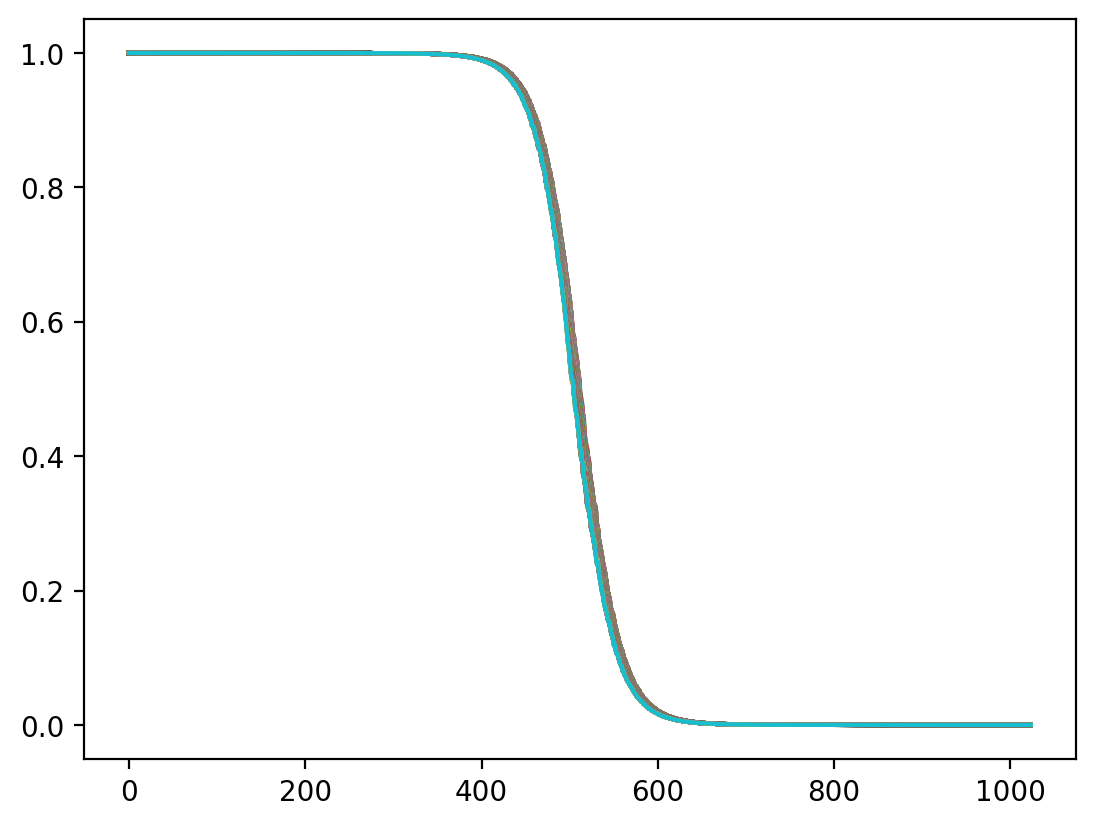

In [14]:
for t in range(t_start, t_start+t_sim):
    plt.plot(runner.mon.r_E[t,:])

In [7]:
runner.mon.theta_E.shape

(1100, 1)

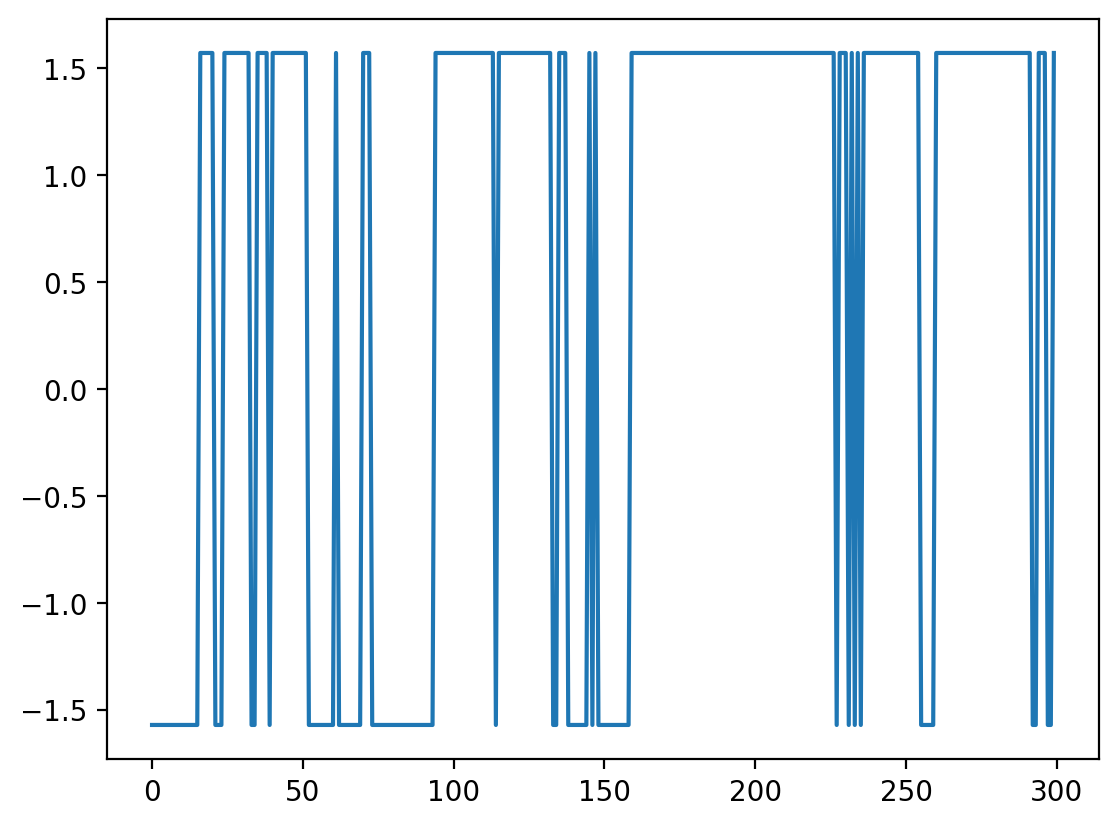

In [10]:
plt.figure()
plt.plot(runner.mon.theta_E[t_start:t_start+t_sim])
#plt.plot(runner.mon.x_E[t_start:t_start+t_sim])
#plt.ylim(-0.4,0.4)

    


    
    
    

In [7]:
pos_E = model.evidence_to_pos(model.x0, model.sigma_E)

array([[1.7900497e-02],
       [9.9988556e-01],
       [3.8820307e-04],
       ...,
       [3.8820307e-04],
       [3.8820307e-04],
       [3.8820307e-04]], shape=(1100, 1), dtype=float32)